# Tox21 SHAP Explainability Validation

Validate model behavior with SHAP on known compounds, inspect global feature signals for `NR-AhR`, and assert key explainability expectations.

## Cell 1 - Imports and Setup

In [5]:
import shap, json, numpy as np, pandas as pd, joblib, sys, matplotlib.pyplot as plt
sys.path.append('../../../')
from backend.app.services.mol_processor import extract_features

with open('../processed/feature_names.json') as f:
    feature_names = json.load(f)

MODELS_DIR = '../trained_models/'
ASSAY_COLUMNS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
    'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

## Cell 2 - Test SHAP on 3 Known Compounds

In [6]:
test_cases = [
    ('CC(=O)Oc1ccccc1C(=O)O', 'Aspirin', 'expected mostly SAFE'),
    ('c1cc2ccc3cccc4ccc(c1)c2c34', 'Pyrene', 'expected TOXIC on NR-AhR'),
    ('CN1C=NC2=C1C(=O)N(C(=O)N2C)C', 'Caffeine', 'expected mostly SAFE'),
]

target_assay = 'NR-AhR'
model = joblib.load(f'{MODELS_DIR}model_{target_assay}.joblib')
explainer = shap.TreeExplainer(model)

prob_by_name = {}
top_features_by_name = {}
shap_tables_by_name = {}

def extract_single_shap_vector(raw_shap_values):
    """Normalize SHAP output shape to a single feature vector for one sample."""
    if isinstance(raw_shap_values, list):
        class_values = raw_shap_values[1] if len(raw_shap_values) > 1 else raw_shap_values[0]
        return np.asarray(class_values).reshape(1, -1)[0]

    arr = np.asarray(raw_shap_values)
    if arr.ndim == 3:  # (n_samples, n_features, n_classes)
        class_idx = 1 if arr.shape[2] > 1 else 0
        return arr[0, :, class_idx]
    if arr.ndim == 2:  # (n_samples, n_features)
        return arr[0]
    if arr.ndim == 1:  # (n_features,)
        return arr

    raise ValueError(f'Unexpected SHAP output shape: {arr.shape}')

for smiles, name, expected in test_cases:
    features = extract_features(smiles)
    if features is None:
        print(f'Invalid SMILES: {name}')
        continue

    raw_shap_values = explainer.shap_values(features.reshape(1, -1))
    sv = extract_single_shap_vector(raw_shap_values)

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': sv,
        'abs_shap': np.abs(sv)
    }).sort_values('abs_shap', ascending=False).head(10)

    prob = model.predict_proba(features.reshape(1, -1))[0, 1]
    prob_by_name[name] = float(prob)
    top_features_by_name[name] = shap_df['feature'].head(5).tolist()
    shap_tables_by_name[name] = shap_df.copy()

    print(f'\n=== {name} ({expected}) ===')
    print(f"Probability: {prob:.3f} | Prediction: {'TOXIC' if prob > 0.5 else 'SAFE'}")
    print(shap_df[['feature', 'shap_value']].to_string(index=False))

print('\nExpected validation:')
print('- Pyrene should show HIGH probability on NR-AhR')
print('- NumAromaticRings should appear among Pyrene key drivers with positive SHAP value')
print('- Aspirin should show LOW probability on NR-AhR')


=== Aspirin (expected mostly SAFE) ===
Probability: 0.011 | Prediction: SAFE
          feature  shap_value
     FractionCSP3   -1.209642
             TPSA   -0.832124
  morgan_bit_1377   -0.558233
NumRotatableBonds   -0.412027
          MolLogP    0.365056
            MolWt   -0.348052
   morgan_bit_285   -0.304432
   morgan_bit_646   -0.275718
           NumHBA    0.236908
  morgan_bit_1991   -0.204058

=== Pyrene (expected TOXIC on NR-AhR) ===
Probability: 0.872 | Prediction: TOXIC
         feature  shap_value
 morgan_bit_1999    0.369923
         MolLogP    0.358217
 morgan_bit_1984    0.272349
NumAromaticRings    0.236240
  morgan_bit_650    0.196447
 morgan_bit_1700   -0.180392
 morgan_bit_1222   -0.137259
           MolWt   -0.135285
   morgan_bit_91    0.120716
 morgan_bit_1057    0.119742

=== Caffeine (expected mostly SAFE) ===
Probability: 0.004 | Prediction: SAFE
        feature  shap_value
        MolLogP   -1.719465
   FractionCSP3   -1.440220
           TPSA   -0.901437


### Chemical Interpretation of the Three Results

- **Pyrene**: Highly fused aromatic rings are consistent with stronger AhR-related toxicity signals, so high predicted probability is chemically plausible.
- **Aspirin**: Smaller and less polyaromatic, usually giving weaker AhR activation signatures and lower predicted toxicity.
- **Caffeine**: Heterocyclic but not a large polycyclic aromatic hydrocarbon, so it is generally expected to be lower-risk for AhR-driven toxicity than pyrene.

## Cell 3 - SHAP Summary Plot for NR-AhR

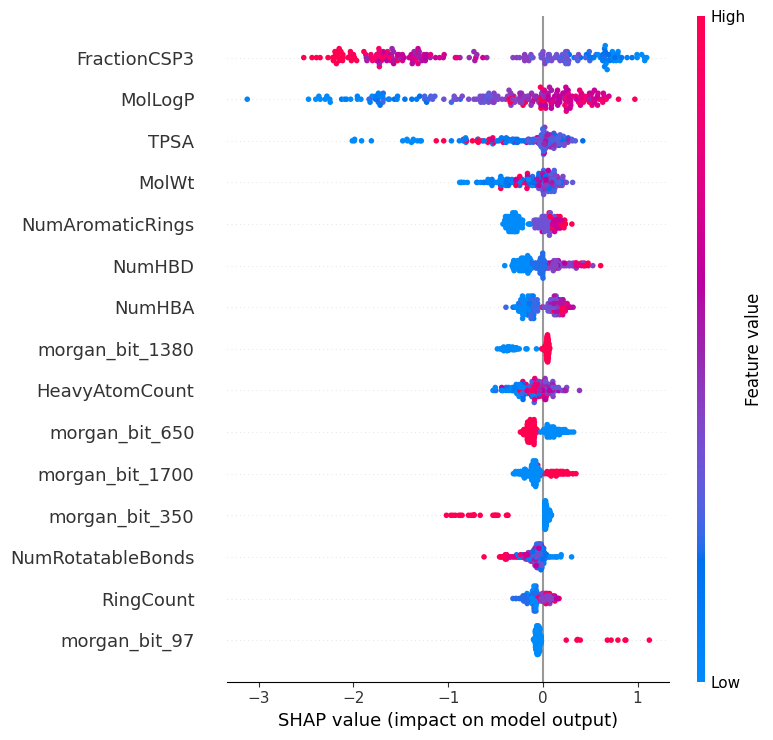

Saved SHAP summary plot


In [7]:
import os

X_all = np.load('../processed/X_processed.npy')
sample_size = min(200, len(X_all))
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(X_all), size=sample_size, replace=False)
X_sample = X_all[sample_indices]

raw_shap_values_sample = explainer.shap_values(X_sample)
if isinstance(raw_shap_values_sample, list):
    shap_values_sample = raw_shap_values_sample[1] if len(raw_shap_values_sample) > 1 else raw_shap_values_sample[0]
else:
    arr = np.asarray(raw_shap_values_sample)
    if arr.ndim == 3:
        class_idx = 1 if arr.shape[2] > 1 else 0
        shap_values_sample = arr[:, :, class_idx]
    elif arr.ndim == 2:
        shap_values_sample = arr
    else:
        raise ValueError(f'Unexpected SHAP sample shape: {arr.shape}')

os.makedirs('../../../docs', exist_ok=True)
shap.summary_plot(
    shap_values_sample,
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig('../../../docs/shap_summary_NR-AhR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved SHAP summary plot')

## Cell 4 - Validation Assertions

In [8]:
prob_pyrene = prob_by_name.get('Pyrene')
prob_aspirin = prob_by_name.get('Aspirin')

assert prob_pyrene is not None and prob_aspirin is not None, 'Missing required compound predictions for validation checks'
assert prob_pyrene > prob_aspirin, 'Pyrene should be more toxic than aspirin on NR-AhR'

top_features_pyrene = top_features_by_name.get('Pyrene', [])
assert any('Aromatic' in f or 'Ring' in f or 'morgan' in f for f in top_features_pyrene), \
    "Ring-related features should drive pyrene's AhR toxicity"

print('✓ All SHAP validation checks passed')

✓ All SHAP validation checks passed


## Cell 5 - Summary

- **SHAP values** quantify directional contribution to the model output: positive values push toward higher toxicity probability, negative values push toward lower probability.
- **Pyrene and AhR**: Pyrene is a polycyclic aromatic hydrocarbon; aromatic ring-heavy structure is mechanistically aligned with stronger AhR-ligand behavior.
- **Aspirin and AhR**: Aspirin is smaller and more polar with less extensive aromaticity, so it is less likely to activate AhR-associated toxicity pathways strongly.
- **Pipeline confirmation**: If pyrene is scored above aspirin and aromatic/ring features dominate pyrene SHAP attribution, then feature engineering, model fitting, and explainability mapping are behaving coherently end-to-end.